Loaded IndoFloods gauges: 155
                 GaugeID  Latitude  Longitude
0  INDOFLOODS-gauge-1013   26.3253    89.2356
1  INDOFLOODS-gauge-1018   26.3325    88.8636
2  INDOFLOODS-gauge-1020   22.8381    87.9031
3  INDOFLOODS-gauge-1042   26.3253    89.2356
4  INDOFLOODS-gauge-1050   26.3089    89.6756
Number of coordinates to sample: 155

--- FSI values at IndoFloods gauge locations ---
Gauge at (26.3253, 89.2356) → FSI = 1.0
Gauge at (26.3325, 88.8636) → FSI = 1.0
Gauge at (22.8381, 87.9031) → FSI = 0.039809372276067734
Gauge at (26.3253, 89.2356) → FSI = 1.0
Gauge at (26.3089, 89.6756) → FSI = 0.16980452835559845
Gauge at (23.6500, 88.1400) → FSI = 0.055182598531246185
Gauge at (26.5628, 88.7583) → FSI = 1.0
Gauge at (24.0031, 88.1375) → FSI = 0.055182598531246185
Gauge at (24.0911, 88.2431) → FSI = 0.055182598531246185
Gauge at (23.3553, 88.6061) → FSI = 0.055182598531246185
Gauge at (22.8381, 87.9031) → FSI = 0.039809372276067734
Gauge at (26.7292, 89.3236) → FSI = 1.0
Gauge at 

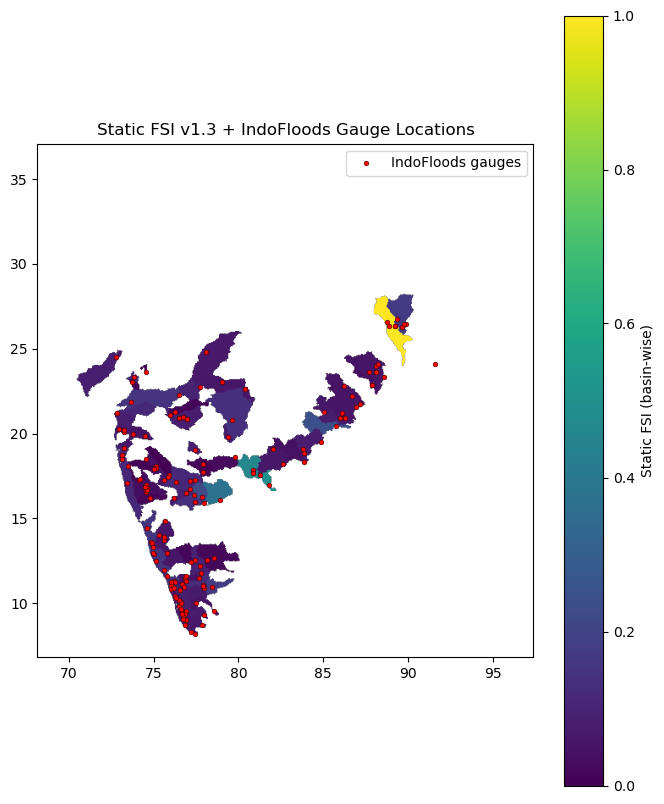

In [7]:
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load IndoFloods gauges (from your CCART module)
# ------------------------------------------------------------
from ccart.flood.fsi.compute_fsi import compute_fsi

gdf = compute_fsi()
print("Loaded IndoFloods gauges:", len(gdf))

# Show first few gauges
print(gdf[['GaugeID','Latitude','Longitude']].head())

# ------------------------------------------------------------
# 2. Build coordinate list for sampling
# ------------------------------------------------------------
coords = list(zip(gdf['Longitude'], gdf['Latitude']))
print("Number of coordinates to sample:", len(coords))

# ------------------------------------------------------------
# 3. Load static FSI raster (basin-wise CHIRPS-aligned)
# ------------------------------------------------------------
fsi_path = r"C:\CMIP_data\cmip6\Climada\Projects\ccart-india\ccart\flood\outputs\fsi\ccart_floods_fsi_static_chirps_rescaled.tif"

with rasterio.open(fsi_path) as src:
    fsi_arr = src.read(1)
    fsi_tf  = src.transform
    fsi_crs = src.crs
    sampled_vals = list(src.sample(coords))

# ------------------------------------------------------------
# 4. Print sampled values
# ------------------------------------------------------------
print("\n--- FSI values at IndoFloods gauge locations ---")
for (lon, lat), v in zip(coords[:20], sampled_vals[:20]):  # show first 20
    print(f"Gauge at ({lat:.4f}, {lon:.4f}) → FSI = {v[0]}")

# Count NaNs
vals = np.array([v[0] for v in sampled_vals])
print("\nTotal gauges:", len(vals))
print("Valid FSI values:", np.isfinite(vals).sum())
print("NaN values:", np.isnan(vals).sum())

# ------------------------------------------------------------
# 5. Plot FSI raster + gauge points
# ------------------------------------------------------------
# Build lon/lat grid for plotting
rows, cols = fsi_arr.shape
lons = np.array([fsi_tf.c + (j + 0.5) * fsi_tf.a for j in range(cols)])
lats = np.array([fsi_tf.f + (i + 0.5) * fsi_tf.e for i in range(rows)])

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(
    fsi_arr,
    origin="upper",
    extent=[lons.min(), lons.max(), lats.min(), lats.max()],
    cmap="viridis"
)

# Plot IndoFloods gauges
ax.scatter(
    gdf['Longitude'], gdf['Latitude'],
    s=12, c="red", edgecolor="black", linewidth=0.3,
    label="IndoFloods gauges"
)

plt.colorbar(im, ax=ax, label="Static FSI (basin-wise)")
ax.set_title("Static FSI v1.3 + IndoFloods Gauge Locations")
ax.legend()
plt.show()


